In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn

In [2]:
#Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [10]:
 #Load Dataset : Load California Housing Dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.

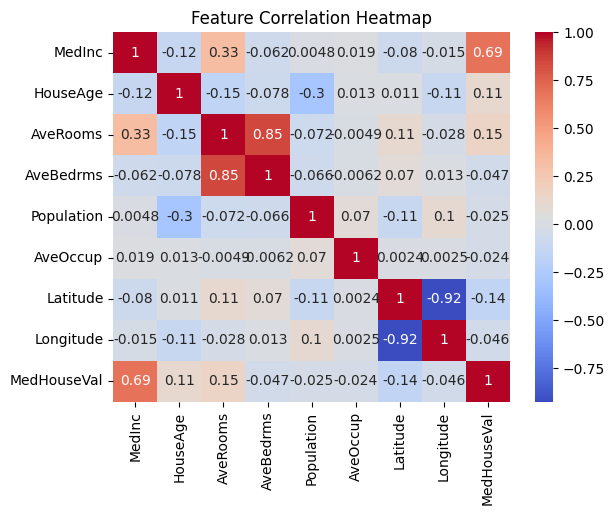

In [11]:
#Data Exploration
print(df.info())
print(df.describe())
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [12]:
#Feature Scaling
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
X_selected = X_scaled

In [16]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

In [17]:
#Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("Linear R²:", r2_score(y_test, y_pred))
print("Linear RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Linear R²: 0.5757877060324511
Linear RMSE: 0.7455813830127761


In [19]:
#Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_selected)
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y, test_size=0.2, random_state=42)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train_poly)
y_pred_poly = poly_model.predict(X_test_poly)

print("Polynomial R²:", r2_score(y_test_poly, y_pred_poly))
print("Polynomial RMSE:", np.sqrt(mean_squared_error(y_test_poly, y_pred_poly)))

Polynomial R²: 0.6456819729261911
Polynomial RMSE: 0.6813967448044651


In [20]:
#Cross-Validation
cv_scores = cross_val_score(lr, X_selected, y, cv=5, scoring='r2')
print("CV R² Scores:", cv_scores)
print("Mean CV Score:", np.mean(cv_scores))

CV R² Scores: [0.54866323 0.46820691 0.55078434 0.53698703 0.66051406]
Mean CV Score: 0.5530311140279561


In [21]:
#Hyperparameter Tuning – Ridge & Lasso
params = {'alpha': [0.01, 0.1, 1, 10, 100]}

ridge = GridSearchCV(Ridge(), params, cv=5)
ridge.fit(X_selected, y)
print("Best Ridge Alpha:", ridge.best_params_)
print("Best Ridge R²:", ridge.best_score_)

lasso = GridSearchCV(Lasso(), params, cv=5)
lasso.fit(X_selected, y)
print("Best Lasso Alpha:", lasso.best_params_)
print("Best Lasso R²:", lasso.best_score_)


Best Ridge Alpha: {'alpha': 10}
Best Ridge R²: 0.5530925208131402
Best Lasso Alpha: {'alpha': 0.01}
Best Lasso R²: 0.5497644182002727


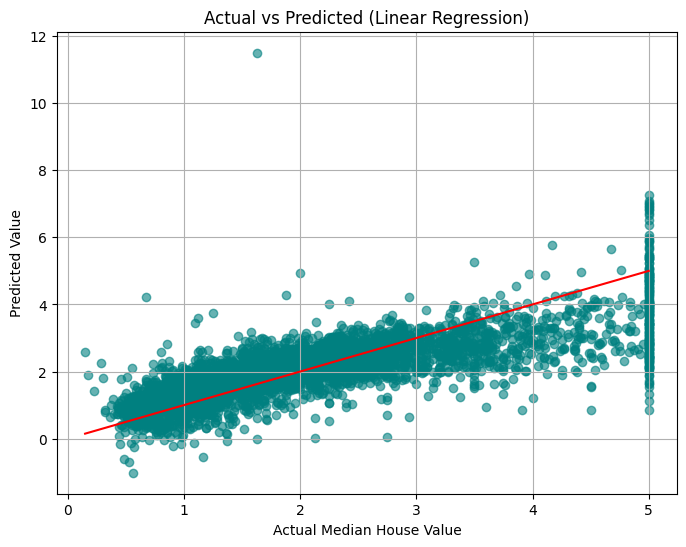

In [23]:
#Visualize Predictions
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Value")
plt.title("Actual vs Predicted (Linear Regression)")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r')
plt.grid(True)
plt.show()